In [ ]:
# Install all required libraries
!pip install -q kagglehub torch torchvision torchaudio scikit-learn pandas matplotlib seaborn

In [ ]:
import os
import copy
import math
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [ ]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

In [ ]:
import kagglehub

path = kagglehub.dataset_download("protobioengineering/mit-bih-arrhythmia-database-modern-2023")
print("Dataset path:", path)

Using Colab cache for faster access to the 'mit-bih-arrhythmia-database-modern-2023' dataset.
Dataset path: /kaggle/input/mit-bih-arrhythmia-database-modern-2023


In [ ]:
for root, dirs, files in os.walk(path):
    print("FOLDER:", root)
    for f in files[:10]:
        print("   ", f)
    if len(files) > 10:
        print(f"   ... and {len(files)-10} more files")

FOLDER: /kaggle/input/mit-bih-arrhythmia-database-modern-2023
    114_ekg.json
    108_annotations_1.csv
    217_ekg.json
    115_annotations_1.csv
    223_annotations_1.json
    123_ekg.json
    215_annotations_2.csv
    202_ekg.json
    114_annotations_1.json
    104_ekg.json
   ... and 192 more files


In [ ]:
all_files = os.listdir(path)

ekg_files = sorted([f for f in all_files if f.endswith("_ekg.csv")])
annotation_files = sorted([f for f in all_files if "_annotations_" in f and f.endswith(".csv")])

print("Number of ECG files:", len(ekg_files))
print("Number of annotation files:", len(annotation_files))

print("\nSample ECG files:", ekg_files[:5])
print("Sample annotation files:", annotation_files[:5])

Number of ECG files: 48
Number of annotation files: 57

Sample ECG files: ['100_ekg.csv', '101_ekg.csv', '102_ekg.csv', '103_ekg.csv', '104_ekg.csv']
Sample annotation files: ['100_annotations_1.csv', '101_annotations_1.csv', '102_annotations_1.csv', '103_annotations_1.csv', '104_annotations_1.csv']


In [ ]:
from collections import defaultdict

patient_data = defaultdict(dict)

for f in ekg_files:
    patient_id = f.split("_")[0]
    patient_data[patient_id]["ekg"] = f

for f in annotation_files:
    patient_id = f.split("_")[0]
    patient_data[patient_id].setdefault("annotations", []).append(f)

print("Number of patients found:", len(patient_data))

# Show a few examples
for i, (pid, info) in enumerate(patient_data.items()):
    print(pid, info)
    if i == 2:
        break

Number of patients found: 48
100 {'ekg': '100_ekg.csv', 'annotations': ['100_annotations_1.csv']}
101 {'ekg': '101_ekg.csv', 'annotations': ['101_annotations_1.csv']}
102 {'ekg': '102_ekg.csv', 'annotations': ['102_annotations_1.csv']}


In [ ]:
# AAMI-like simplified 5-class grouping
# N = normal and related
# S = supraventricular ectopic
# V = ventricular ectopic
# F = fusion
# Q = unknown / paced / unclassifiable / others

label_map = {
    # Normal group
    "N": "N", "L": "N", "R": "N", "e": "N", "j": "N",

    # Supraventricular group
    "A": "S", "a": "S", "J": "S", "S": "S",

    # Ventricular group
    "V": "V", "E": "V",

    # Fusion group
    "F": "F",

    # Unknown / other group
    "/": "Q", "f": "Q", "Q": "Q"
}

valid_classes = ["N", "S", "V", "F", "Q"]
print("Valid classes:", valid_classes)

Valid classes: ['N', 'S', 'V', 'F', 'Q']


In [ ]:
def find_signal_columns(df):
    """
    Tries to identify ECG signal columns from the EKG CSV.
    Based on the dataset description, common columns may include:
    - index
    - first lead
    - second lead
    - symbol (sometimes)
    We will prefer numeric columns except obvious index/time columns.
    """
    numeric_cols = []
    for col in df.columns:
        if pd.api.types.is_numeric_dtype(df[col]):
            numeric_cols.append(col)

    return numeric_cols

In [ ]:
sample_pid = sorted(patient_data.keys())[0]

sample_ekg_path = os.path.join(path, patient_data[sample_pid]["ekg"])
sample_ann_path = os.path.join(path, patient_data[sample_pid]["annotations"][0])

ekg_sample_df = pd.read_csv(sample_ekg_path)
ann_sample_df = pd.read_csv(sample_ann_path)

print("Sample patient ID:", sample_pid)
print("\nECG columns:")
print(ekg_sample_df.columns.tolist())

print("\nAnnotation columns:")
print(ann_sample_df.columns.tolist())

print("\nECG head:")
display(ekg_sample_df.head())

print("\nAnnotation head:")
display(ann_sample_df.head())

Sample patient ID: 100

ECG columns:
['Unnamed: 0', 'MLII', 'V5', 'symbol']

Annotation columns:
['index', 'annotation_symbol']

ECG head:


,Unnamed: 0,MLII,V5,symbol
0,0,-0.145,-0.065,NaN
1,1,-0.145,-0.065,NaN
2,2,-0.145,-0.065,NaN
3,3,-0.145,-0.065,NaN
4,4,-0.145,-0.065,NaN



Annotation head:


,index,annotation_symbol
0,18,+
1,77,N
2,370,N
3,662,N
4,946,N


In [ ]:
# We want each heartbeat sample to have fixed length 187
# Example: 90 points before beat and 96 after = 187 total
window_before = 90
window_after = 96
segment_length = window_before + window_after + 1

print("Segment length:", segment_length)

Segment length: 187


In [ ]:
def extract_heartbeat_segments_from_patient(ekg_path, annotation_paths, label_map,
                                            window_before=90, window_after=96):
    """
    Reads one patient's ECG and annotation files, then extracts heartbeat-centered segments.

    Returns:
        segments: list of numpy arrays of shape (segment_length,)
        labels: list of mapped class labels
        patient_ids: list of patient IDs for each segment
    """
    ekg_df = pd.read_csv(ekg_path)

    # Find numeric columns in ECG file
    numeric_cols = find_signal_columns(ekg_df)

    if len(numeric_cols) < 2:
        raise ValueError(f"Not enough numeric columns found in {ekg_path}")

    # Choose lead signal:
    # usually first numeric col may be index, second/third may be leads
    # safest approach: use the last numeric signal column if index is included
    # or the first true signal-like column after index
    if len(numeric_cols) >= 3:
        signal_col = numeric_cols[1]   # usually first lead after index
    else:
        signal_col = numeric_cols[-1]

    signal = ekg_df[signal_col].values.astype(np.float32)

    segments = []
    labels = []
    patient_ids = []

    patient_id = os.path.basename(ekg_path).split("_")[0]

    for ann_path in annotation_paths:
        ann_df = pd.read_csv(ann_path)

        # Expected columns: index, annotation_symbol
        if "index" not in ann_df.columns or "annotation_symbol" not in ann_df.columns:
            continue

        for _, row in ann_df.iterrows():
            beat_index = int(row["index"])
            symbol = str(row["annotation_symbol"]).strip()

            # skip labels we do not map
            if symbol not in label_map:
                continue

            mapped_label = label_map[symbol]

            start = beat_index - window_before
            end = beat_index + window_after + 1

            # skip incomplete windows near boundaries
            if start < 0 or end > len(signal):
                continue

            segment = signal[start:end]

            if len(segment) == (window_before + window_after + 1):
                segments.append(segment)
                labels.append(mapped_label)
                patient_ids.append(patient_id)

    return segments, labels, patient_ids

In [ ]:
all_segments = []
all_labels = []
all_patient_ids = []

for patient_id, info in patient_data.items():
    if "ekg" not in info or "annotations" not in info:
        continue

    ekg_path = os.path.join(path, info["ekg"])
    ann_paths = [os.path.join(path, f) for f in info["annotations"]]

    try:
        segments, labels, patient_ids = extract_heartbeat_segments_from_patient(
            ekg_path,
            ann_paths,
            label_map,
            window_before=window_before,
            window_after=window_after
        )

        all_segments.extend(segments)
        all_labels.extend(labels)
        all_patient_ids.extend(patient_ids)

        print(f"Processed patient {patient_id}: {len(segments)} segments")

    except Exception as e:
        print(f"Skipping patient {patient_id} بسبب error: {e}")

print("\nTotal heartbeat segments:", len(all_segments))
print("Total labels:", len(all_labels))
print("Total patient IDs:", len(all_patient_ids))

Processed patient 100: 2271 segments
Processed patient 101: 1864 segments
Processed patient 102: 2187 segments
Processed patient 103: 2084 segments
Processed patient 104: 2228 segments
Processed patient 105: 2572 segments
Processed patient 106: 2027 segments
Processed patient 107: 2137 segments
Processed patient 108: 3524 segments
Processed patient 109: 2531 segments
Processed patient 111: 2124 segments
Processed patient 112: 2539 segments
Processed patient 113: 1794 segments
Processed patient 114: 1879 segments
Processed patient 115: 1952 segments
Processed patient 116: 2411 segments
Processed patient 117: 3068 segments
Processed patient 118: 2277 segments
Processed patient 119: 3974 segments
Processed patient 121: 1863 segments
Processed patient 122: 2475 segments
Processed patient 123: 1517 segments
Processed patient 124: 1619 segments
Processed patient 200: 2600 segments
Processed patient 201: 1963 segments
Processed patient 202: 2136 segments
Processed patient 203: 8940 segments
P

In [ ]:
X = np.array(all_segments, dtype=np.float32)
y_labels = np.array(all_labels)
patient_ids = np.array(all_patient_ids)

print("X shape:", X.shape)
print("y_labels shape:", y_labels.shape)

print("\nClass distribution:")
print(pd.Series(y_labels).value_counts())

X shape: (131818, 187)
y_labels shape: (131818,)

Class distribution:
N    110571
V      9004
Q      8052
S      3383
F       808
Name: count, dtype: int64


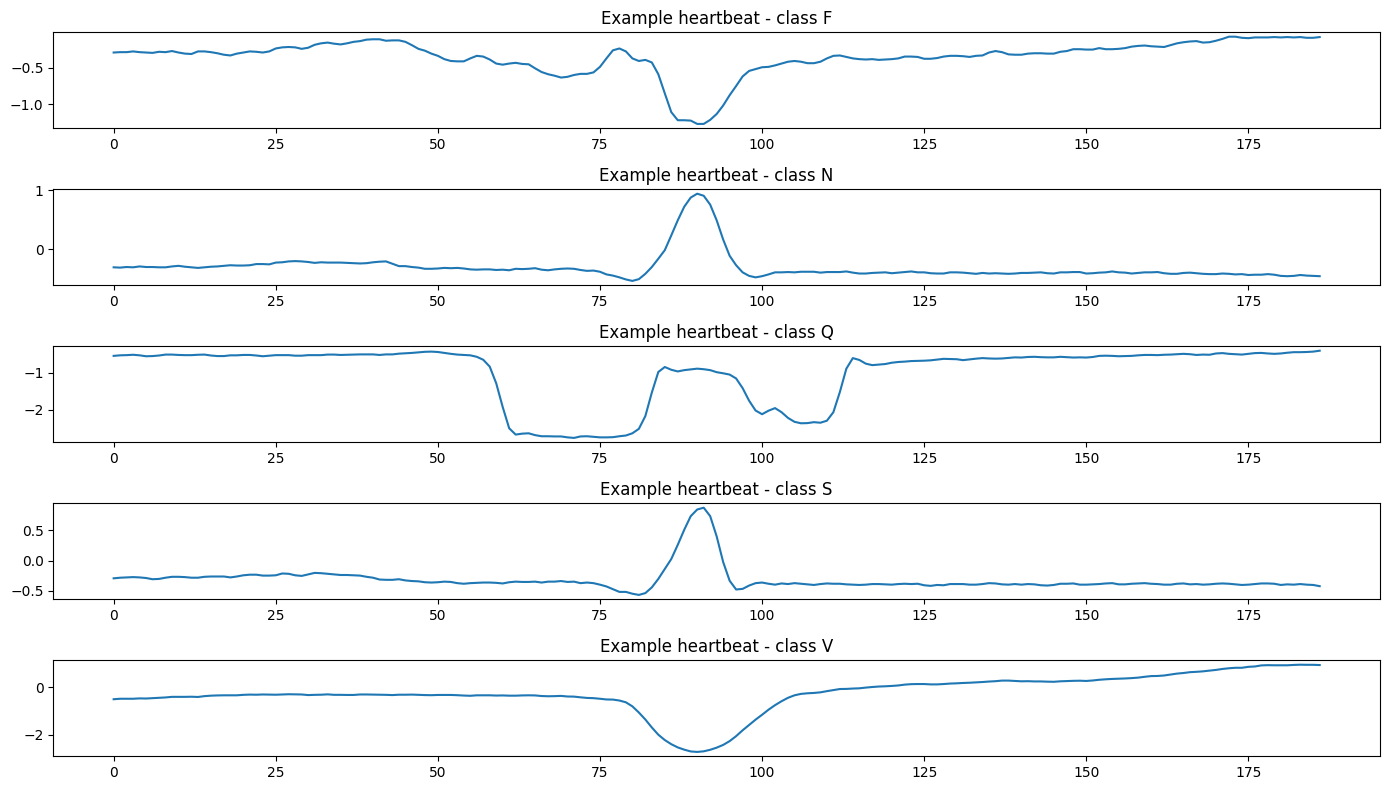

In [ ]:
unique_classes = sorted(np.unique(y_labels))

plt.figure(figsize=(14, 8))

for i, cls in enumerate(unique_classes):
    idx = np.where(y_labels == cls)[0][0]
    plt.subplot(len(unique_classes), 1, i+1)
    plt.plot(X[idx])
    plt.title(f"Example heartbeat - class {cls}")
    plt.tight_layout()

plt.show()

In [ ]:
# Normalize each heartbeat independently
X_min = X.min(axis=1, keepdims=True)
X_max = X.max(axis=1, keepdims=True)

X = (X - X_min) / (X_max - X_min + 1e-8)

print("Normalized X shape:", X.shape)
print("Example min/max:", X[0].min(), X[0].max())

Normalized X shape: (131818, 187)
Example min/max: 0.0 1.0


In [ ]:
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y_labels)

print("Classes:", label_encoder.classes_)
print("Encoded labels example:", y[:10])

Classes: ['F' 'N' 'Q' 'S' 'V']
Encoded labels example: [1 1 1 1 1 1 3 1 1 1]


In [ ]:
# To avoid leakage, split by patient IDs, not by individual beats
unique_patients = np.unique(patient_ids)
print("Unique patients:", len(unique_patients))

train_patients, test_patients = train_test_split(
    unique_patients,
    test_size=0.2,
    random_state=42
)

train_mask = np.isin(patient_ids, train_patients)
test_mask = np.isin(patient_ids, test_patients)

X_train_full = X[train_mask]
y_train_full = y[train_mask]

X_test = X[test_mask]
y_test = y[test_mask]

print("Train full shape:", X_train_full.shape, y_train_full.shape)
print("Test shape:", X_test.shape, y_test.shape)

Unique patients: 48
Train full shape: (100865, 187) (100865,)
Test shape: (30953, 187) (30953,)


In [ ]:
# To avoid leakage, split by patient IDs, not by individual beats
unique_patients = np.unique(patient_ids)
print("Unique patients:", len(unique_patients))

train_patients, test_patients = train_test_split(
    unique_patients,
    test_size=0.2,
    random_state=42
)

train_mask = np.isin(patient_ids, train_patients)
test_mask = np.isin(patient_ids, test_patients)

X_train_full = X[train_mask]
y_train_full = y[train_mask]

X_test = X[test_mask]
y_test = y[test_mask]

print("Train full shape:", X_train_full.shape, y_train_full.shape)
print("Test shape:", X_test.shape, y_test.shape)

Unique patients: 48
Train full shape: (100865, 187) (100865,)
Test shape: (30953, 187) (30953,)


In [ ]:
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.15,
    random_state=42,
    stratify=y_train_full
)

print("Train:", X_train.shape, y_train.shape)
print("Validation:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)

Train: (85735, 187) (85735,)
Validation: (15130, 187) (15130,)
Test: (30953, 187) (30953,)


In [ ]:
class ECGDataset(Dataset):
    def __init__(self, X, y=None):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = None if y is None else torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        if self.y is None:
            return self.X[idx]
        return self.X[idx], self.y[idx]

In [ ]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=500):
        super().__init__()

        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float32).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))

        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)

        pe = pe.unsqueeze(0)
        self.register_buffer("pe", pe)

    def forward(self, x):
        seq_len = x.size(1)
        return x + self.pe[:, :seq_len, :]

In [ ]:
class ECGTransformerClassifier(nn.Module):
    def __init__(self, seq_len=187, num_classes=5, d_model=64, nhead=4, num_layers=2,
                 dim_feedforward=128, dropout=0.2):
        super().__init__()

        self.input_projection = nn.Linear(1, d_model)
        self.pos_encoder = PositionalEncoding(d_model, max_len=seq_len)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True
        )
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(d_model, num_classes)

    def forward(self, x):
        x = x.unsqueeze(-1)           # (batch, seq_len, 1)
        x = self.input_projection(x)  # (batch, seq_len, d_model)
        x = self.pos_encoder(x)
        x = self.transformer_encoder(x)
        x = x.mean(dim=1)             # global average pooling
        x = self.dropout(x)
        x = self.classifier(x)
        return x

In [ ]:
class ECGTransformerPretrainer(nn.Module):
    def __init__(self, seq_len=187, d_model=64, nhead=4, num_layers=2,
                 dim_feedforward=128, dropout=0.2):
        super().__init__()

        self.input_projection = nn.Linear(1, d_model)
        self.pos_encoder = PositionalEncoding(d_model, max_len=seq_len)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True
        )
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.reconstruction_head = nn.Linear(d_model, 1)

    def forward(self, x):
        x = x.unsqueeze(-1)
        x = self.input_projection(x)
        x = self.pos_encoder(x)
        x = self.transformer_encoder(x)
        x = self.reconstruction_head(x)
        return x.squeeze(-1)

In [ ]:
def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss = 0
    preds_all = []
    labels_all = []

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        preds = torch.argmax(outputs, dim=1)

        preds_all.extend(preds.cpu().numpy())
        labels_all.extend(y_batch.cpu().numpy())

    acc = accuracy_score(labels_all, preds_all)
    return total_loss / len(loader), acc


def evaluate(model, loader, criterion):
    model.eval()
    total_loss = 0
    preds_all = []
    labels_all = []

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)

            total_loss += loss.item()
            preds = torch.argmax(outputs, dim=1)

            preds_all.extend(preds.cpu().numpy())
            labels_all.extend(y_batch.cpu().numpy())

    acc = accuracy_score(labels_all, preds_all)
    return total_loss / len(loader), acc, preds_all, labels_all


def fit_model(model, train_loader, val_loader, criterion, optimizer, epochs=10, model_name="model.pt"):
    best_val_acc = 0
    best_weights = copy.deepcopy(model.state_dict())

    history = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": []
    }

    for epoch in range(epochs):
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer)
        val_loss, val_acc, _, _ = evaluate(model, val_loader, criterion)

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        print(f"Epoch {epoch+1}/{epochs} | "
              f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
              f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_weights = copy.deepcopy(model.state_dict())

    model.load_state_dict(best_weights)
    torch.save(model.state_dict(), model_name)
    print("Best validation accuracy:", round(best_val_acc, 4))
    return model, history


def plot_history(history, title="Training History"):
    epochs = range(1, len(history["train_loss"]) + 1)

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, history["train_loss"], label="Train Loss")
    plt.plot(epochs, history["val_loss"], label="Val Loss")
    plt.title(f"{title} - Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs, history["train_acc"], label="Train Acc")
    plt.plot(epochs, history["val_acc"], label="Val Acc")
    plt.title(f"{title} - Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()

    plt.show()

In [ ]:
print("X_train exists:", 'X_train' in globals())
print("X_val exists:", 'X_val' in globals())
print("X_test exists:", 'X_test' in globals())
print("y_train exists:", 'y_train' in globals())
print("y_val exists:", 'y_val' in globals())
print("y_test exists:", 'y_test' in globals())

X_train exists: True
X_val exists: True
X_test exists: True
y_train exists: True
y_val exists: True
y_test exists: True


In [ ]:
from torch.utils.data import Dataset, DataLoader
import torch

class ECGDataset(Dataset):
    def __init__(self, X, y=None):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = None if y is None else torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        if self.y is None:
            return self.X[idx]
        return self.X[idx], self.y[idx]

In [ ]:
batch_size = 128

train_dataset = ECGDataset(X_train, y_train)
val_dataset = ECGDataset(X_val, y_val)
test_dataset = ECGDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# unlabeled dataset for self-supervised pretraining later
pretrain_dataset = ECGDataset(X_train)
pretrain_loader = DataLoader(pretrain_dataset, batch_size=batch_size, shuffle=True)

print("train_loader ready")
print("Number of training batches:", len(train_loader))
print("Number of validation batches:", len(val_loader))
print("Number of test batches:", len(test_loader))

train_loader ready
Number of training batches: 670
Number of validation batches: 119
Number of test batches: 242


Number of classes: 5
Epoch 1/12 | Train Loss: 0.3180 | Train Acc: 0.9122 | Val Loss: 0.1789 | Val Acc: 0.9501
Epoch 2/12 | Train Loss: 0.1557 | Train Acc: 0.9565 | Val Loss: 0.1700 | Val Acc: 0.9471
Epoch 3/12 | Train Loss: 0.1168 | Train Acc: 0.9676 | Val Loss: 0.0948 | Val Acc: 0.9760
Epoch 4/12 | Train Loss: 0.0963 | Train Acc: 0.9736 | Val Loss: 0.0871 | Val Acc: 0.9783
Epoch 5/12 | Train Loss: 0.0853 | Train Acc: 0.9773 | Val Loss: 0.0837 | Val Acc: 0.9794
Epoch 6/12 | Train Loss: 0.0756 | Train Acc: 0.9805 | Val Loss: 0.0735 | Val Acc: 0.9820
Epoch 7/12 | Train Loss: 0.0701 | Train Acc: 0.9812 | Val Loss: 0.0681 | Val Acc: 0.9822
Epoch 8/12 | Train Loss: 0.0634 | Train Acc: 0.9829 | Val Loss: 0.0592 | Val Acc: 0.9843
Epoch 9/12 | Train Loss: 0.0602 | Train Acc: 0.9835 | Val Loss: 0.0733 | Val Acc: 0.9803
Epoch 10/12 | Train Loss: 0.0559 | Train Acc: 0.9849 | Val Loss: 0.0668 | Val Acc: 0.9853
Epoch 11/12 | Train Loss: 0.0524 | Train Acc: 0.9863 | Val Loss: 0.0545 | Val Acc: 0.986

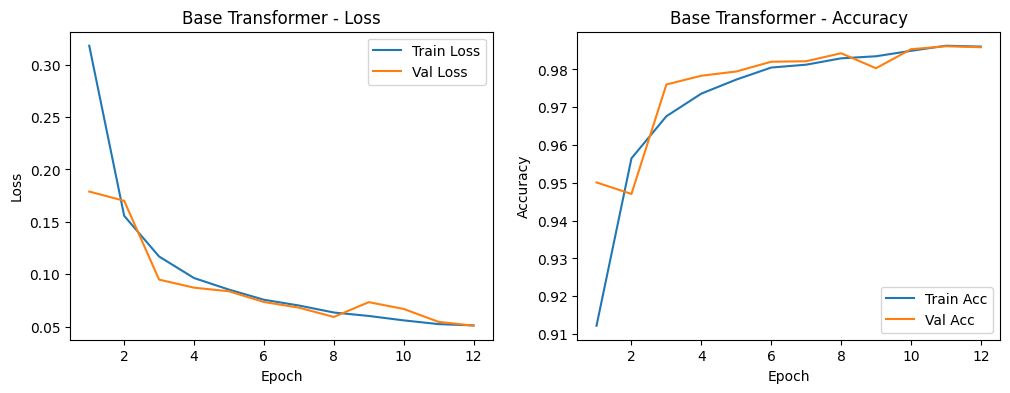

In [ ]:
#Base
num_classes = len(label_encoder.classes_)
print("Number of classes:", num_classes)

base_model = ECGTransformerClassifier(seq_len=187, num_classes=num_classes).to(device)

criterion_base = nn.CrossEntropyLoss()
optimizer_base = torch.optim.Adam(base_model.parameters(), lr=1e-3)

base_model, history_base = fit_model(
    base_model,
    train_loader,
    val_loader,
    criterion_base,
    optimizer_base,
    epochs=12,
    model_name="base_transformer.pt"
)

plot_history(history_base, title="Base Transformer")

In [ ]:
test_loss_base, test_acc_base, y_pred_base, y_true_base = evaluate(base_model, test_loader, criterion_base)

print("Base Transformer Test Accuracy:", round(test_acc_base, 4))
print("\nClassification Report:\n")
print(classification_report(y_true_base, y_pred_base, target_names=label_encoder.classes_))

Base Transformer Test Accuracy: 0.7585

Classification Report:

              precision    recall  f1-score   support

           F       0.00      0.06      0.01        18
           N       0.95      0.76      0.85     26548
           Q       0.95      0.77      0.85      2075
           S       0.13      0.16      0.14       624
           V       0.22      0.88      0.35      1688

    accuracy                           0.76     30953
   macro avg       0.45      0.53      0.44     30953
weighted avg       0.89      0.76      0.81     30953



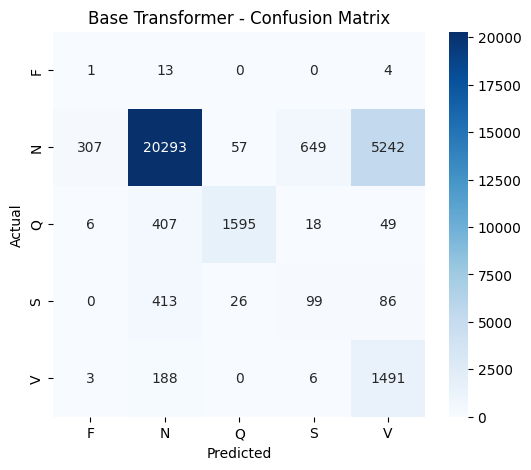

In [ ]:
cm = confusion_matrix(y_true_base, y_pred_base)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.title("Base Transformer - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
classes = np.unique(y_train)
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(device)
print("Class weights:", class_weights)

Class weights: [25.51636905  0.24009017  3.3753937   7.31215352  2.75719569]


Epoch 1/8 | Train Loss: 0.1686 | Train Acc: 0.9431 | Val Loss: 0.1909 | Val Acc: 0.9366
Epoch 2/8 | Train Loss: 0.1511 | Train Acc: 0.9467 | Val Loss: 0.1667 | Val Acc: 0.9475
Epoch 3/8 | Train Loss: 0.1412 | Train Acc: 0.9497 | Val Loss: 0.1714 | Val Acc: 0.9262
Epoch 4/8 | Train Loss: 0.1343 | Train Acc: 0.9460 | Val Loss: 0.1995 | Val Acc: 0.9358
Epoch 5/8 | Train Loss: 0.1335 | Train Acc: 0.9478 | Val Loss: 0.1977 | Val Acc: 0.9361
Epoch 6/8 | Train Loss: 0.1268 | Train Acc: 0.9488 | Val Loss: 0.1512 | Val Acc: 0.9693
Epoch 7/8 | Train Loss: 0.1197 | Train Acc: 0.9505 | Val Loss: 0.1692 | Val Acc: 0.9250
Epoch 8/8 | Train Loss: 0.1192 | Train Acc: 0.9497 | Val Loss: 0.1956 | Val Acc: 0.9342
Best validation accuracy: 0.9693


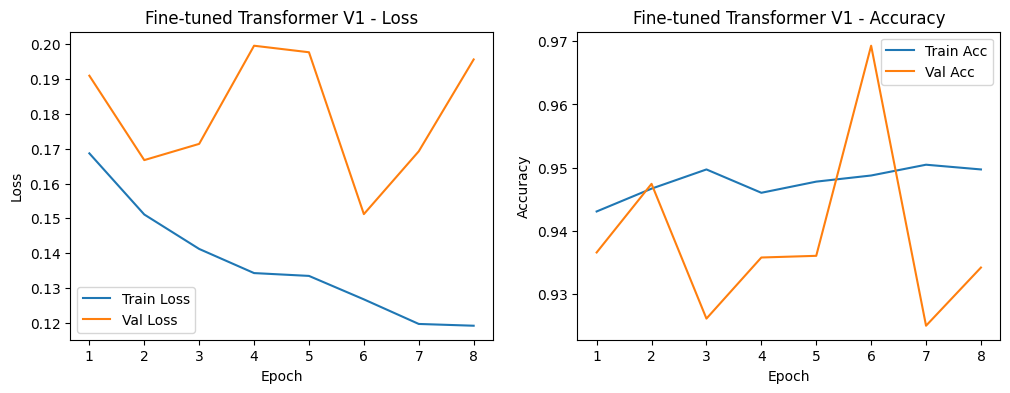

In [ ]:
#fine tune 1
ft1_model = ECGTransformerClassifier(seq_len=187, num_classes=num_classes).to(device)
ft1_model.load_state_dict(torch.load("base_transformer.pt"))

criterion_ft1 = nn.CrossEntropyLoss(weight=class_weights_tensor)
optimizer_ft1 = torch.optim.Adam(ft1_model.parameters(), lr=5e-4)

ft1_model, history_ft1 = fit_model(
    ft1_model,
    train_loader,
    val_loader,
    criterion_ft1,
    optimizer_ft1,
    epochs=8,
    model_name="finetuned_transformer_v1.pt"
)

plot_history(history_ft1, title="Fine-tuned Transformer V1")

In [ ]:
test_loss_ft1, test_acc_ft1, y_pred_ft1, y_true_ft1 = evaluate(ft1_model, test_loader, criterion_ft1)

print("Fine-tuned Transformer V1 Test Accuracy:", round(test_acc_ft1, 4))
print("\nClassification Report:\n")
print(classification_report(y_true_ft1, y_pred_ft1, target_names=label_encoder.classes_))

Fine-tuned Transformer V1 Test Accuracy: 0.6387

Classification Report:

              precision    recall  f1-score   support

           F       0.00      0.28      0.00        18
           N       0.97      0.62      0.76     26548
           Q       0.83      0.83      0.83      2075
           S       0.13      0.37      0.19       624
           V       0.21      0.82      0.34      1688

    accuracy                           0.64     30953
   macro avg       0.43      0.58      0.42     30953
weighted avg       0.90      0.64      0.73     30953



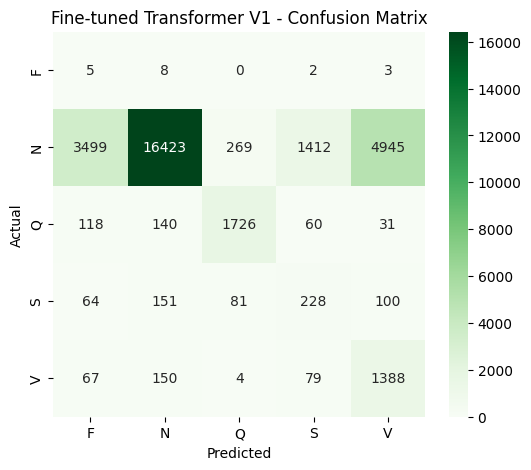

In [ ]:
cm = confusion_matrix(y_true_ft1, y_pred_ft1)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens",
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.title("Fine-tuned Transformer V1 - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
def mask_input(x, mask_ratio=0.15):
    x_masked = x.clone()
    mask = torch.rand(x.shape, device=x.device) < mask_ratio
    x_masked[mask] = 0.0
    return x_masked, mask

In [ ]:
pretrain_model = ECGTransformerPretrainer(seq_len=187).to(device)

optimizer_pretrain = torch.optim.Adam(pretrain_model.parameters(), lr=1e-3)
criterion_pretrain = nn.MSELoss()

pretrain_epochs = 8

for epoch in range(pretrain_epochs):
    pretrain_model.train()
    total_loss = 0

    for X_batch in pretrain_loader:
        X_batch = X_batch.to(device)

        X_masked, mask = mask_input(X_batch, mask_ratio=0.15)

        optimizer_pretrain.zero_grad()
        reconstructed = pretrain_model(X_masked)

        # only compute loss on masked positions
        if mask.sum() == 0:
            continue

        loss = criterion_pretrain(reconstructed[mask], X_batch[mask])
        loss.backward()
        optimizer_pretrain.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(pretrain_loader)
    print(f"Pretrain Epoch {epoch+1}/{pretrain_epochs} | Loss: {avg_loss:.4f}")

Pretrain Epoch 1/8 | Loss: 0.0142
Pretrain Epoch 2/8 | Loss: 0.0023
Pretrain Epoch 3/8 | Loss: 0.0014
Pretrain Epoch 4/8 | Loss: 0.0010
Pretrain Epoch 5/8 | Loss: 0.0008
Pretrain Epoch 6/8 | Loss: 0.0007
Pretrain Epoch 7/8 | Loss: 0.0006
Pretrain Epoch 8/8 | Loss: 0.0006


In [ ]:
ft2_model = ECGTransformerClassifier(seq_len=187, num_classes=num_classes).to(device)

ft2_state = ft2_model.state_dict()
pretrain_state = pretrain_model.state_dict()

for name in ft2_state:
    if name in pretrain_state and ft2_state[name].shape == pretrain_state[name].shape:
        ft2_state[name] = pretrain_state[name]

ft2_model.load_state_dict(ft2_state)
print("Pretrained weights transferred.")

Pretrained weights transferred.


Epoch 1/10 | Train Loss: 0.7352 | Train Acc: 0.5104 | Val Loss: 0.5005 | Val Acc: 0.7303
Epoch 2/10 | Train Loss: 0.3922 | Train Acc: 0.7866 | Val Loss: 0.3676 | Val Acc: 0.8780
Epoch 3/10 | Train Loss: 0.3275 | Train Acc: 0.8354 | Val Loss: 0.3456 | Val Acc: 0.7360
Epoch 4/10 | Train Loss: 0.2904 | Train Acc: 0.8674 | Val Loss: 0.2554 | Val Acc: 0.8731
Epoch 5/10 | Train Loss: 0.2537 | Train Acc: 0.8897 | Val Loss: 0.2854 | Val Acc: 0.7980
Epoch 6/10 | Train Loss: 0.2341 | Train Acc: 0.9012 | Val Loss: 0.2170 | Val Acc: 0.9395
Epoch 7/10 | Train Loss: 0.2263 | Train Acc: 0.9066 | Val Loss: 0.2197 | Val Acc: 0.9304
Epoch 8/10 | Train Loss: 0.2160 | Train Acc: 0.9085 | Val Loss: 0.2208 | Val Acc: 0.9410
Epoch 9/10 | Train Loss: 0.1982 | Train Acc: 0.9178 | Val Loss: 0.2045 | Val Acc: 0.8830
Epoch 10/10 | Train Loss: 0.1904 | Train Acc: 0.9204 | Val Loss: 0.1966 | Val Acc: 0.9173
Best validation accuracy: 0.941


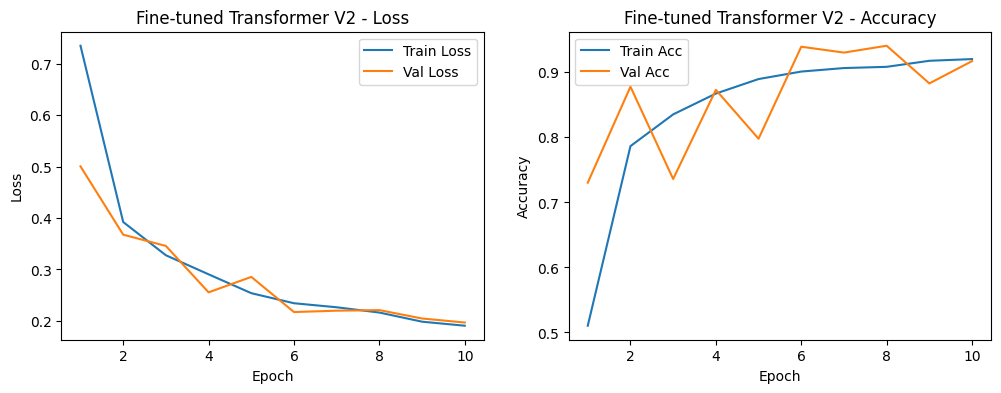

In [ ]:
criterion_ft2 = nn.CrossEntropyLoss(weight=class_weights_tensor)
optimizer_ft2 = torch.optim.Adam(ft2_model.parameters(), lr=5e-4)

ft2_model, history_ft2 = fit_model(
    ft2_model,
    train_loader,
    val_loader,
    criterion_ft2,
    optimizer_ft2,
    epochs=10,
    model_name="finetuned_transformer_v2.pt"
)

plot_history(history_ft2, title="Fine-tuned Transformer V2")

In [ ]:
test_loss_ft2, test_acc_ft2, y_pred_ft2, y_true_ft2 = evaluate(ft2_model, test_loader, criterion_ft2)

print("Fine-tuned Transformer V2 Test Accuracy:", round(test_acc_ft2, 4))
print("\nClassification Report:\n")
print(classification_report(y_true_ft2, y_pred_ft2, target_names=label_encoder.classes_))

Fine-tuned Transformer V2 Test Accuracy: 0.5509

Classification Report:

              precision    recall  f1-score   support

           F       0.00      0.06      0.00        18
           N       0.96      0.53      0.68     26548
           Q       0.78      0.69      0.73      2075
           S       0.09      0.43      0.15       624
           V       0.15      0.83      0.25      1688

    accuracy                           0.55     30953
   macro avg       0.39      0.51      0.36     30953
weighted avg       0.89      0.55      0.65     30953



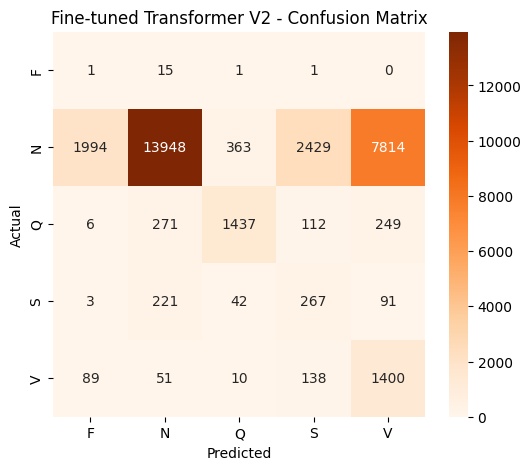

In [ ]:
cm = confusion_matrix(y_true_ft2, y_pred_ft2)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Oranges",
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.title("Fine-tuned Transformer V2 - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
results_df = pd.DataFrame({
    "Model": [
        "Base Transformer",
        "Fine-tuned Transformer V1",
        "Fine-tuned Transformer V2"
    ],
    "Test Accuracy": [
        round(test_acc_base, 4),
        round(test_acc_ft1, 4),
        round(test_acc_ft2, 4)
    ]
})

print(results_df)

                       Model  Test Accuracy
0           Base Transformer         0.7585
1  Fine-tuned Transformer V1         0.6387
2  Fine-tuned Transformer V2         0.5509


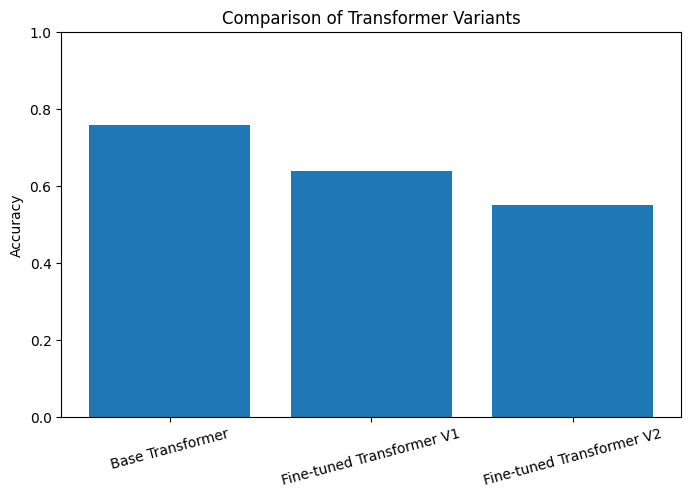

In [ ]:
plt.figure(figsize=(8, 5))
plt.bar(results_df["Model"], results_df["Test Accuracy"])
plt.title("Comparison of Transformer Variants")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.xticks(rotation=15)
plt.show()

In [ ]:
best_row = results_df.iloc[results_df["Test Accuracy"].idxmax()]
print("Best Model:", best_row["Model"])
print("Best Accuracy:", best_row["Test Accuracy"])

Best Model: Base Transformer
Best Accuracy: 0.7585
